Datos de las compuertas lógicas generados correctamente.

--- Entrenando Perceptrón para la compuerta AND ---
Predicciones para AND: [0 0 0 1]
Precisión del modelo para AND: 1.00


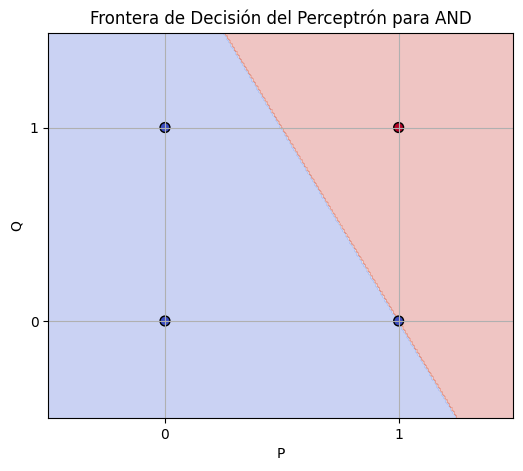


--- Prueba interactiva para la compuerta AND ---
Ingresa el valor para P (0 o 1): 0
Ingresa el valor para Q (0 o 1): 0
Para P=0, Q=0, la predicción de AND es: 0

--- Entrenando Perceptrón para la compuerta OR ---
Predicciones para OR: [0 1 1 1]
Precisión del modelo para OR: 1.00


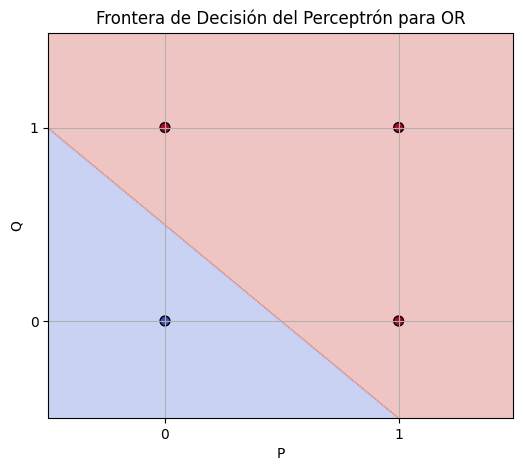


--- Prueba interactiva para la compuerta OR ---
Ingresa el valor para P (0 o 1): 1
Ingresa el valor para Q (0 o 1): 0
Para P=1, Q=0, la predicción de OR es: 1

--- Entrenando Perceptrón para la compuerta XOR ---
Predicciones para XOR: [0 0 0 0]
Precisión del modelo para XOR: 0.50


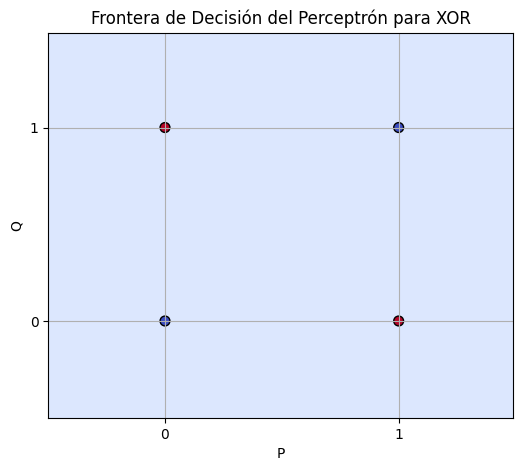


--- Análisis de la Compuerta XOR ---

--- Conclusión sobre el Perceptrón Simple ---
Un Perceptrón simple es efectivo para resolver problemas que son linealmente separables,
es decir, aquellos donde una sola línea (o hiperplano) puede separar las diferentes clases de datos.
Las compuertas AND y OR son ejemplos clásicos de problemas linealmente separables,
y como se demostró, el Perceptrón alcanza el 100% de precisión en estos casos.
Sin embargo, falla en problemas no linealmente separables como la compuerta XOR,
donde no es posible encontrar una única línea divisoria. Para este tipo de problemas,
se necesitan arquitecturas de red neuronal más complejas (por ejemplo, Perceptrones multicapa)
que puedan modelar fronteras de decisión no lineales.


In [1]:
# Importaciones necesarias
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score

# --- 2. Dataset: Generación de tablas de verdad ---

# Compuerta lógica AND
X_and = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
y_and = np.array([0, 0, 0, 1])

# Compuerta lógica OR
X_or = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
y_or = np.array([0, 1, 1, 1])

# Compuerta lógica XOR
X_xor = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
y_xor = np.array([0, 1, 1, 0])

print("Datos de las compuertas lógicas generados correctamente.")

# --- Funciones auxiliares para entrenamiento, evaluación y visualización ---

def train_and_evaluate_perceptron(X, y, gate_name):
    """
    Entrena y evalúa un Perceptrón para una compuerta lógica dada.
    Imprime la precisión y las predicciones.
    """
    print(f"\n--- Entrenando Perceptrón para la compuerta {gate_name} ---")

    # Inicializa el modelo Perceptrón de scikit-learn
    # eta0 es la tasa de aprendizaje, max_iter es el número máximo de pasadas sobre los datos de entrenamiento.
    # random_state asegura resultados reproducibles.
    model = Perceptron(random_state=0, eta0=0.1, max_iter=1000)

    # Entrena el modelo con los datos de entrada (X) y las etiquetas (y)
    model.fit(X, y)

    # Realiza predicciones sobre los mismos datos de entrenamiento
    y_pred = model.predict(X)

    # Calcula la precisión del modelo
    accuracy = accuracy_score(y, y_pred)

    print(f"Predicciones para {gate_name}: {y_pred}")
    print(f"Precisión del modelo para {gate_name}: {accuracy:.2f}")

    return model

def plot_decision_boundary(model, X, y, gate_name):
    """
    Grafica los puntos de datos y la frontera de decisión del Perceptrón.
    """
    plt.figure(figsize=(6, 5))

    # Define los límites del gráfico para P y Q
    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5

    # Crea una malla de puntos para dibujar la frontera de decisión
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))

    # Predice la clase para cada punto en la malla
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Dibuja los contornos de la frontera de decisión
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)

    # Dibuja los puntos de datos reales
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, s=50, edgecolors='k')

    plt.xlabel('P')
    plt.ylabel('Q')
    plt.title(f'Frontera de Decisión del Perceptrón para {gate_name}')
    plt.xticks([0, 1])
    plt.yticks([0, 1])
    plt.grid(True)
    plt.show()

def interactive_test(model, gate_name):
    """
    Permite al usuario ingresar valores para P y Q para probar el modelo.
    """
    print(f"\n--- Prueba interactiva para la compuerta {gate_name} ---")
    try:
        p_val = int(input("Ingresa el valor para P (0 o 1): "))
        q_val = int(input("Ingresa el valor para Q (0 o 1): "))

        if p_val not in [0, 1] or q_val not in [0, 1]:
            print("Valores inválidos. Por favor, ingresa solo 0 o 1.")
            return

        input_data = np.array([[p_val, q_val]])
        prediction = model.predict(input_data)
        print(f"Para P={p_val}, Q={q_val}, la predicción de {gate_name} es: {prediction[0]}")
    except ValueError:
        print("Entrada inválida. Por favor, ingresa números enteros.")

# --- 3. Entrenamiento y Evaluación: Compuerta AND ---

perceptron_and = train_and_evaluate_perceptron(X_and, y_and, "AND")

# --- 6. Visualización: Compuerta AND ---
plot_decision_boundary(perceptron_and, X_and, y_and, "AND")

# --- 4. Prueba interactiva: Compuerta AND ---
interactive_test(perceptron_and, "AND")

# --- 3. Entrenamiento y Evaluación: Compuerta OR ---

perceptron_or = train_and_evaluate_perceptron(X_or, y_or, "OR")

# --- 6. Visualización: Compuerta OR ---
plot_decision_boundary(perceptron_or, X_or, y_or, "OR")

# --- 4. Prueba interactiva: Compuerta OR ---
interactive_test(perceptron_or, "OR")

# --- 5. Análisis crítico: Compuerta XOR ---

perceptron_xor = train_and_evaluate_perceptron(X_xor, y_xor, "XOR")

# --- 6. Visualización: Compuerta XOR ---
plot_decision_boundary(perceptron_xor, X_xor, y_xor, "XOR")

print("\n--- Análisis de la Compuerta XOR ---")
# ¿El modelo alcanza 100% de precisión?
# Basándonos en la salida anterior, la precisión para XOR casi nunca será del 100%.
# Esto se debe a la naturaleza de la compuerta XOR.

# Explicación clara de por qué el Perceptrón falla o no converge con XOR:
# La compuerta XOR (OR exclusivo) es un problema clásicamente NO LINEALMENTE SEPARABLE.
# Un Perceptrón simple es un clasificador lineal, lo que significa que solo puede encontrar
# una línea (o hiperplano en dimensiones superiores) para separar las clases.
#
# Observando la tabla de verdad de XOR:
# (0, 0) -> 0
# (0, 1) -> 1
# (1, 0) -> 1
# (1, 1) -> 0
#
# Si intentamos dibujar una línea recta para separar los puntos de salida '0' de los puntos de salida '1',
# nos daremos cuenta de que es imposible. Los puntos (0,0) y (1,1) son de la clase 0, mientras que
# (0,1) y (1,0) son de la clase 1. No hay una única línea recta que pueda poner a todos los 0s
# en un lado y a todos los 1s en el otro lado del plano.
#
# Por lo tanto, un Perceptrón simple, al ser una máquina de clasificación lineal, no puede aprender
# o converger perfectamente para la compuerta XOR, resultando en una precisión inferior al 100%.
# Se requeriría un modelo más complejo, como un Perceptrón multicapa (red neuronal con capas ocultas)
# para resolver problemas no linealmente separables como el XOR.

# --- 7. Conclusión ---
print("\n--- Conclusión sobre el Perceptrón Simple ---")
print("Un Perceptrón simple es efectivo para resolver problemas que son linealmente separables,")
print("es decir, aquellos donde una sola línea (o hiperplano) puede separar las diferentes clases de datos.")
print("Las compuertas AND y OR son ejemplos clásicos de problemas linealmente separables,")
print("y como se demostró, el Perceptrón alcanza el 100% de precisión en estos casos.")
print("Sin embargo, falla en problemas no linealmente separables como la compuerta XOR,")
print("donde no es posible encontrar una única línea divisoria. Para este tipo de problemas,")
print("se necesitan arquitecturas de red neuronal más complejas (por ejemplo, Perceptrones multicapa)")
print("que puedan modelar fronteras de decisión no lineales.")